In [1]:
!pip install ultralytics roboflow opencv-python matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 145.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15


In [2]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from roboflow import Roboflow

rf = Roboflow(api_key="THDOzejgorUN6TgTFyZr")

project = rf.workspace("csi-sgqu2").project("trees-counting")

dataset = project.version(2).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Trees-Counting-2 in yolov8:: 100%|██████████| 14580/14580 [00:03<00:00, 3946.21it/s]


In [4]:
model = YOLO("yolov8n.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=20,
    imgsz=640
)

Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Trees-Counting-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7aa5d8cb4560>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [5]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/detect/train/weights/best.pt"
)

In [6]:
results = model.predict(
    source=f"{dataset.location}/test/images",
    conf=0.25,
    save=True
)


image 1/281 /content/Trees-Counting-2/test/images/12_jpeg_jpg.rf.63cfcb204abd7eb7ec1a8d298a2c0923.jpg: 640x640 21 objects, 9.0ms
image 2/281 /content/Trees-Counting-2/test/images/2018_SJER_3_252000_4104000_image_628_jpeg_jpg.rf.92eaba5dbfa9c09b23c9a5fe645efa5a.jpg: 640x640 6 objects, 20.0ms
image 3/281 /content/Trees-Counting-2/test/images/2018_SJER_3_252000_4104000_image_628_jpeg_jpg.rf.94f3a5c568166d9385d0151f486fefe7.jpg: 640x640 6 objects, 20.5ms
image 4/281 /content/Trees-Counting-2/test/images/2018_SJER_3_252000_4107000_image_372_jpeg_jpg.rf.71248d10892252dc3cb17da5f9808875.jpg: 640x640 3 objects, 22.4ms
image 5/281 /content/Trees-Counting-2/test/images/2018_SJER_3_253000_4104000_image_637_jpeg_jpg.rf.db97a3c4bff80e370e0ee1dac2e47e8f.jpg: 640x640 5 objects, 19.1ms
image 6/281 /content/Trees-Counting-2/test/images/2018_SJER_3_254000_4107000_image_670_jpeg_jpg.rf.8cf9bcb94015664ccc7e52d26a42f376.jpg: 640x640 13 objects, 13.7ms
image 7/281 /content/Trees-Counting-2/test/images/2018

In [7]:
for i, result in enumerate(results):
    print(
        f"Image {i+1}: {len(result.boxes)} trees"
    )

Image 1: 21 trees
Image 2: 6 trees
Image 3: 6 trees
Image 4: 3 trees
Image 5: 5 trees
Image 6: 13 trees
Image 7: 8 trees
Image 8: 8 trees
Image 9: 8 trees
Image 10: 5 trees
Image 11: 6 trees
Image 12: 14 trees
Image 13: 21 trees
Image 14: 23 trees
Image 15: 5 trees
Image 16: 14 trees
Image 17: 14 trees
Image 18: 6 trees
Image 19: 6 trees
Image 20: 111 trees
Image 21: 33 trees
Image 22: 27 trees
Image 23: 12 trees
Image 24: 48 trees
Image 25: 19 trees
Image 26: 51 trees
Image 27: 17 trees
Image 28: 56 trees
Image 29: 17 trees
Image 30: 7 trees
Image 31: 30 trees
Image 32: 75 trees
Image 33: 4 trees
Image 34: 85 trees
Image 35: 7 trees
Image 36: 7 trees
Image 37: 59 trees
Image 38: 38 trees
Image 39: 38 trees
Image 40: 38 trees
Image 41: 27 trees
Image 42: 25 trees
Image 43: 17 trees
Image 44: 52 trees
Image 45: 15 trees
Image 46: 15 trees
Image 47: 35 trees
Image 48: 46 trees
Image 49: 58 trees
Image 50: 56 trees
Image 51: 56 trees
Image 52: 49 trees
Image 53: 50 trees
Image 54: 40 tree

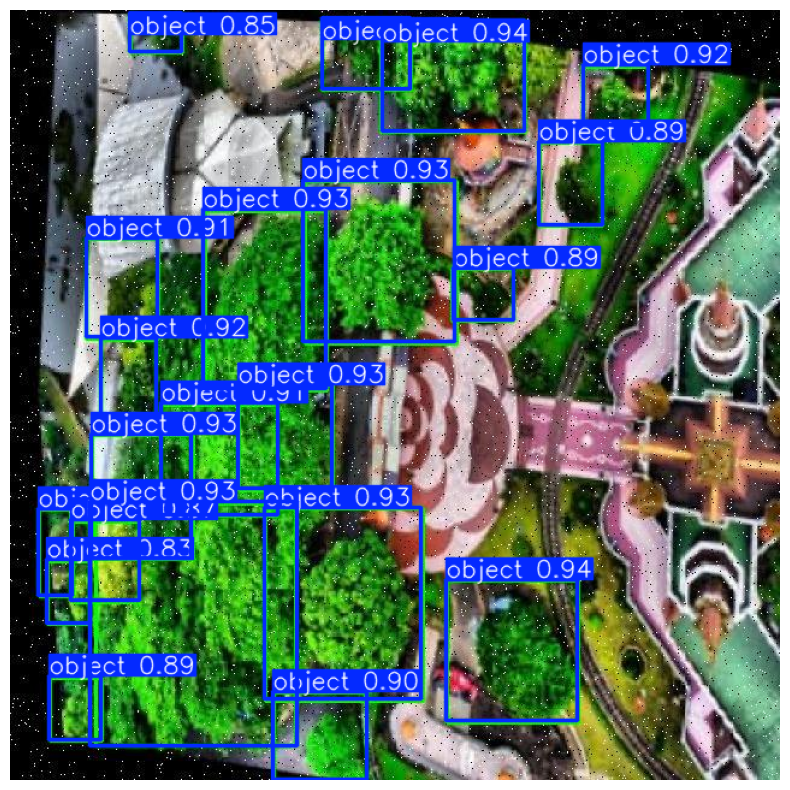

In [8]:
import matplotlib.pyplot as plt
import cv2

img = results[0].plot()

plt.figure(figsize=(10,10))
plt.imshow(
    cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
)
plt.axis("off")
plt.show()

In [9]:
import pandas as pd

data = []

for i, result in enumerate(results):

    data.append({
        "Image": f"Image_{i+1}",
        "Tree_Count": len(result.boxes)
    })

df = pd.DataFrame(data)

df.to_csv(
    "tree_report.csv",
    index=False
)

df

,Image,Tree_Count
0,Image_1,21
1,Image_2,6
2,Image_3,6
3,Image_4,3
4,Image_5,5
...,...,...
276,Image_277,13
277,Image_278,14
278,Image_279,9
279,Image_280,9


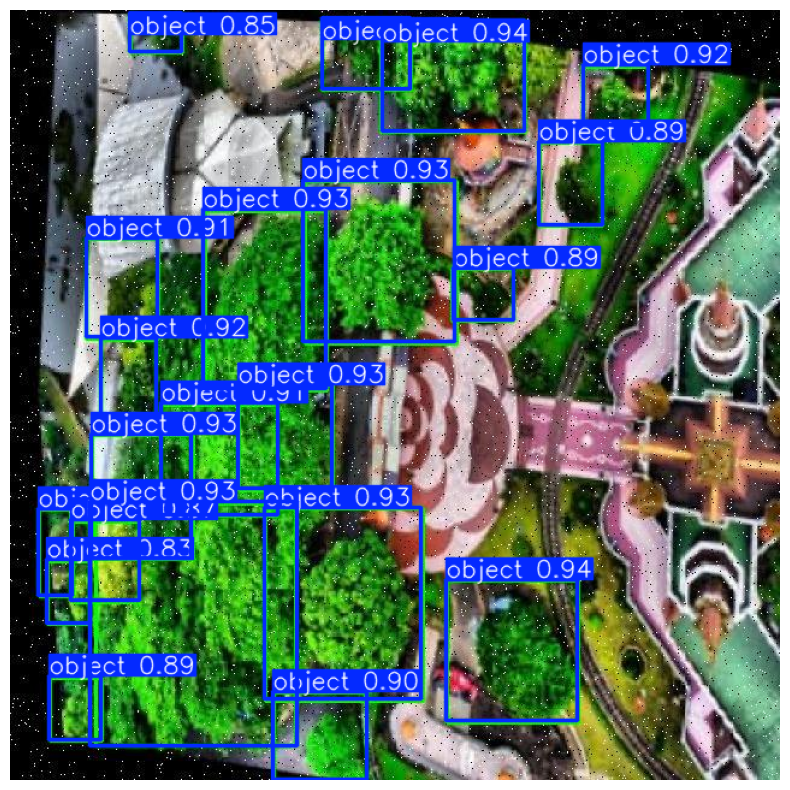

In [10]:
import matplotlib.pyplot as plt
import cv2

img = results[0].plot()

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

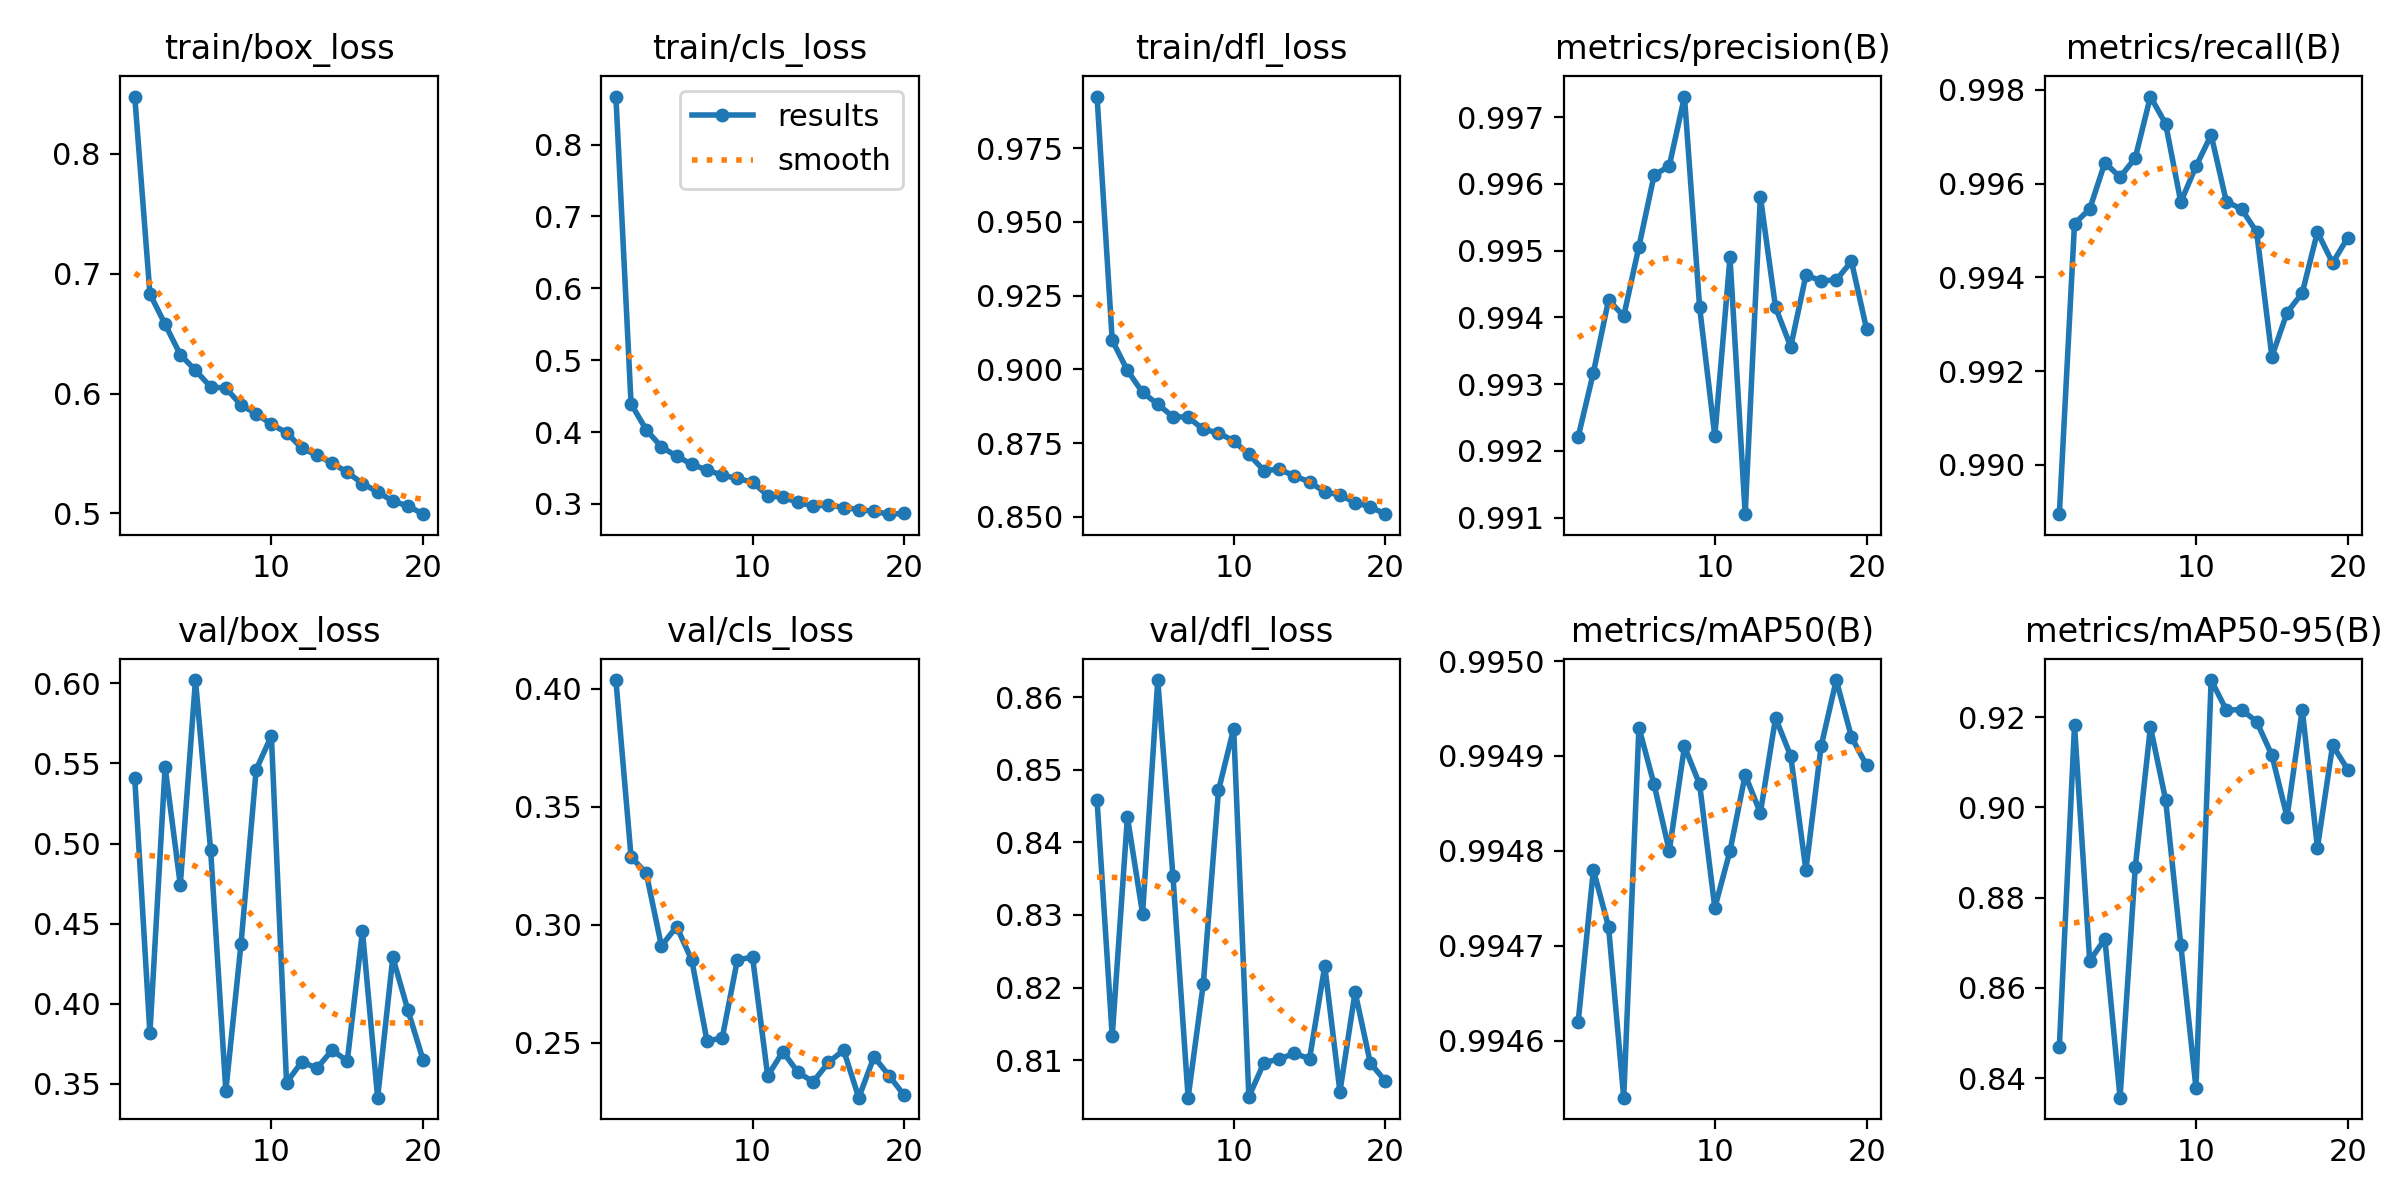

In [11]:
from IPython.display import Image

Image('/content/runs/detect/train/results.png', width=900)

In [12]:
from google.colab import files

files.download("tree_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
from google.colab import files

files.download(
    "/content/runs/detect/train/weights/best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>